In [1]:
# ==================== CIFAKE (REAL vs FAKE) CNN TRAINING — STEP 0: GPU CHECK ====================
!nvidia-smi                 # show which GPU Colab assigned (T4 / L4 / A100). "command not found" = no GPU -> change runtime type
!pip install -q -U gdown    # upgrade gdown (Google-Drive downloader) to the newest version; -q keeps the log short

Tue Sep 29 15:55:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ==================== STEP 1: IMPORTS & REPRODUCIBILITY ====================
import os                      # os: operating-system helpers — build paths, list folders, create directories
import re                      # re: regular expressions — used to pull the file/folder ID out of a Drive link
import time                    # time: measure how long each training run takes
import copy                    # copy: deepcopy() lets us keep a frozen snapshot of the best model weights
import random                  # random: Python's built-in random generator (seeded for reproducibility)
import shutil                  # shutil: high-level file operations — unpack_archive() extracts .zip/.tar files
import warnings                # warnings: lets us silence harmless library warnings
import traceback               # traceback: prints the full error if one dataset fails, without stopping the others

import numpy as np             # numpy: fast numeric arrays; sklearn metrics work on numpy arrays
import pandas as pd            # pandas: DataFrames (tables) — used for the dataset-vs-dataset comparison
import matplotlib.pyplot as plt  # matplotlib: learning curves and bar charts
import seaborn as sns          # seaborn: nicer heatmaps (confusion matrices)
from PIL import Image          # Pillow: opens image files; we use it to detect corrupt images

import torch                                      # PyTorch core: tensors + automatic differentiation
import torch.nn as nn                             # nn: layers (Conv2d, Linear, ...) and losses (CrossEntropyLoss)
from torch.utils.data import DataLoader, Subset   # DataLoader = batching/shuffling/parallel loading; Subset = pick items by index
from torchvision import datasets, transforms, models  # image datasets, image pre-processing, pretrained models

from sklearn.model_selection import train_test_split  # stratified splitting of indices into train/val/test
from sklearn.metrics import (accuracy_score, precision_score, recall_score,   # scalar metrics
                             f1_score, confusion_matrix, classification_report)  # matrix + per-class text report

import gdown                   # gdown: download from Google Drive share links

warnings.filterwarnings("ignore", category=UserWarning)   # hide UserWarnings (e.g. odd EXIF data) so the log stays readable

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # use the GPU if Colab gave us one, otherwise CPU
print("PyTorch version :", torch.__version__)       # printing versions helps when you search an error online
print("Running on      :", DEVICE)                  # should say "cuda"
if DEVICE.type == "cuda":                           # only when a GPU exists...
    print("GPU             :", torch.cuda.get_device_name(0))  # ...print its model name, e.g. "Tesla T4"

try:                                   # detect whether we're inside Google Colab
    from google.colab import drive     # this module exists only inside Colab (used to mount your Drive)
    IN_COLAB = True                    # remember: yes, Colab
except ImportError:                    # import fails anywhere else (e.g. Jupyter on your laptop)
    IN_COLAB = False                   # remember: not Colab

BASE_DIR = "/content" if IN_COLAB else os.getcwd()  # Colab's writable work folder is /content; elsewhere use the current folder


def set_seed(seed=42):
    # Same seed -> same weight initialisation, same shuffling, same train/val/test split -> fair comparisons.
    random.seed(seed)                        # seed Python's RNG
    np.random.seed(seed)                     # seed NumPy's RNG
    torch.manual_seed(seed)                  # seed PyTorch's CPU RNG (weight init, dropout masks, ...)
    torch.cuda.manual_seed_all(seed)         # seed the RNG on every GPU
    torch.backends.cudnn.benchmark = True    # let cuDNN pick the fastest convolution algorithm for our input size

print("Imports OK. In Colab:", IN_COLAB)     # sanity message

PyTorch version : 2.11.0+cu128
Running on      : cuda
GPU             : Tesla T4
Imports OK. In Colab: True


In [3]:
# ==================== STEP 2: PASTE YOUR DRIVE LINK + SETTINGS ====================
# The code auto-detects what is inside: train/ + test/ folders, each with REAL/ and FAKE/ sub-folders.

DATASET_LINK = "https://drive.google.com/drive/u/0/folders/17AjXkjFDDvlJuBwFa0_MF3lixur_ayYb"

DATASETS = [                                                       # list of datasets to train on (CIFAKE first)
    {"name": "cifake", "link": DATASET_LINK},                      # the link you pasted above
    # {"name": "another_dataset", "link": "PASTE_ANOTHER_LINK"},   # optional: uncomment to train & compare a 2nd dataset
]

CONFIG = {                                   # every hyper-parameter in one place, so experiments are easy to log & repeat
    "model": "simple_cnn",                   # "simple_cnn" (train from scratch) or "resnet18" (pretrained + fine-tune)
    "image_size": 32,                        # CIFAKE images are natively 32x32 — keep them at their real size
    "batch_size": 128,                       # small images -> bigger batches fit easily and train faster
    "epochs": 30,                            # upper limit on passes through the training data
    "lr": 1e-3,                              # learning rate for AdamW
    "weight_decay": 1e-4,                    # regularisation strength (AdamW's decoupled weight decay)
    "dropout": 0.3,                          # 30% of classifier neurons dropped at random during training
    "label_smoothing": 0.1,                  # target 1.0 becomes 0.9 (rest spread over other classes)
    "augment": True,                         # random flips/crops/rotations/colour jitter on training images
    "val_split": 0.15,                       # 15% of images for validation (used to pick the best epoch)
    "test_split": 0.15,                      # 15% of images for the final, untouched test score
    "patience": 6,                           # early-stop after 6 epochs with no validation-F1 improvement
    "freeze_epochs": 3,                      # (resnet18 only) epochs training only the new final layer
    "finetune_lr_factor": 0.1,               # (resnet18 only) LR multiplier once the whole network is unfrozen
    "use_class_weights": False,              # True = rare classes weigh more in the loss (imbalanced data)
    "use_amp": True,                         # mixed-precision training on GPU (faster, less memory)
    "verify_images": False,                  # CIFAKE is clean; scanning 120k files would just waste minutes
    "num_workers": 2,                        # background processes loading images (Colab has 2 CPU cores)
    "seed": 42,                              # random seed -> reproducible splits & initialisation
    "show_plots": True,                      # draw sample images, learning curves and confusion matrices per dataset
    "data_root": os.path.join(BASE_DIR, "data"),        # where datasets get downloaded/extracted
    "save_dir": os.path.join(BASE_DIR, "results"),      # where checkpoints and the results CSV are written
    "save_to_drive": False,                  # True = also copy results into MyDrive/cnn_results (safe against Colab disconnects)
}
print(f"{len(DATASETS)} dataset entr{'y' if len(DATASETS)==1 else 'ies'} configured.")  # quick confirmation

1 dataset entry configured.


In [4]:
import glob                                                     # glob: find files matching a pattern
from google.colab import files                                  # Colab's file-upload helper

zips = glob.glob("/content/*.zip")                              # any zip already uploaded in this session?
if zips:                                                        # yes -> reuse it, no upload
    zip_path = zips[0]
    print("Already uploaded, reusing:", zip_path)
else:                                                           # no -> ask for the file
    uploaded = files.upload()                                   # pick the CIFAKE zip from your Desktop
    zip_path = "/content/" + next(iter(uploaded))               # full path of the uploaded zip
    print("Uploaded:", zip_path)

DATASETS = [{"name": "cifake", "path": zip_path}]               # tell the notebook to use it

Already uploaded, reusing: /content/CIFAKE-Real-and-AI-Generated-Synthetic-Images-main.zip


In [5]:
# ==================== STEP 3: DOWNLOAD & LOCATE THE DATA ====================
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff")   # file types we treat as images
ARCHIVE_EXTS = (".zip", ".tar", ".tar.gz", ".tgz", ".tar.bz2", ".tar.xz")       # file types we auto-extract
SPLIT_NAMES = {                                                                 # folder names we recognise as pre-made splits
    "train": {"train", "training"},                                            # any of these -> training set
    "val":   {"val", "valid", "validation", "dev"},                            # any of these -> validation set
    "test":  {"test", "testing"},                                              # any of these -> test set
}


def parse_drive_link(link):
    # Return ("folder" | "file", ID) for any common Google Drive link format.
    link = link.strip()                                                   # remove accidental spaces/newlines from copy-paste
    m = re.search(r"/folders/([A-Za-z0-9_-]+)", link)                     # folder links: .../drive/folders/<ID>
    if m:                                                                 # matched a folder link
        return "folder", m.group(1)                                       # group(1) = the text captured inside ( )
    m = re.search(r"/d/([A-Za-z0-9_-]+)", link) or re.search(r"[?&]id=([A-Za-z0-9_-]+)", link)  # file: .../file/d/<ID>/ or ...?id=<ID>
    if m:                                                                 # matched a file link
        return "file", m.group(1)                                         # return the file ID
    if re.fullmatch(r"[A-Za-z0-9_-]{20,}", link):                         # user pasted just the bare ID
        return "file", link                                               # treat it as a file ID
    raise ValueError(f"Couldn't find a Google Drive ID in: {link}")       # anything else is unusable -> clear error


def is_archive(path):
    return os.path.isfile(path) and path.lower().endswith(ARCHIVE_EXTS)   # True for an existing .zip/.tar/... file


def extract(archive_path, dest):
    print(f"   📦 extracting {os.path.basename(archive_path)} ...")        # tell the user what's happening
    shutil.unpack_archive(archive_path, dest)                             # unzip / untar into dest (format from extension)


def mount_drive_if_needed(path):
    if IN_COLAB and path.startswith("/content/drive") and not os.path.exists("/content/drive/MyDrive"):  # a Drive path, not yet mounted
        drive.mount("/content/drive")                                     # pops up the permission dialog, then mounts Drive


def fetch_dataset(entry):
    # Make the dataset available locally and return the folder that contains it.
    name = entry["name"]                                                  # the dataset's label
    dest = os.path.join(CONFIG["data_root"], name)                        # e.g. /content/data/dataset_1

    if "path" in entry:                                                   # ── option A: a path in your mounted Drive ──
        src = entry["path"]                                               # the path you typed
        mount_drive_if_needed(src)                                        # mount Drive first if the path lives there
        if not os.path.exists(src):                                       # typo or not mounted?
            raise FileNotFoundError(f"Path not found: {src}")             # stop with a clear message
        if is_archive(src):                                               # a zip inside Drive -> extract to fast local disk
            if not os.path.exists(os.path.join(dest, ".ready")):          # only if we haven't extracted it already
                os.makedirs(dest, exist_ok=True)                          # create the destination folder
                extract(src, dest)                                        # unpack it
                open(os.path.join(dest, ".ready"), "w").close()           # empty marker file = "done, don't redo"
            return dest                                                   # use the extracted copy
        return src                                                        # a plain folder: read it straight from Drive

    kind, drive_id = parse_drive_link(entry["link"])                      # ── option B: a share link ──
    marker = os.path.join(dest, ".ready")                                 # marker file that says "download finished"
    if os.path.exists(marker):                                            # downloaded in an earlier run?
        print(f"   ✔ using cached copy in {dest}")                        # skip the download
        return dest                                                       # and reuse it
    os.makedirs(dest, exist_ok=True)                                      # make /content/data/<name>

    if kind == "folder":                                                  # a shared Drive folder
        print(f"   ⬇ downloading Drive folder {drive_id} ...")            # progress message
        print("   ⚠ folder links with ~120k images are VERY slow and may be rate-limited by Google —"
              " if this stalls, share the dataset as a single .zip file and paste that link instead")
        gdown.download_folder(id=drive_id, output=dest, quiet=False)      # download every file in the folder (keeps sub-folders)
    else:                                                                 # a single file (normally a zip)
        print(f"   ⬇ downloading Drive file {drive_id} ...")              # progress message
        out = gdown.download(id=drive_id, output=dest + os.sep, quiet=False)  # trailing "/" = keep the original file name
        if out is None:                                                   # gdown returns None if Google refused the download
            raise RuntimeError("Download failed. Is the link shared as 'Anyone with the link'?")  # most common cause

    for dirpath, _, files in os.walk(dest):                               # look through everything we downloaded
        for f in files:                                                   # every file...
            p = os.path.join(dirpath, f)                                  # ...full path
            if is_archive(p):                                             # if it's a zip/tar
                extract(p, dirpath)                                       # unpack it next to itself
                os.remove(p)                                              # delete the archive to save disk space
    open(marker, "w").close()                                             # mark this dataset as downloaded
    return dest                                                           # the folder that now holds the data


def list_subdirs(path):
    # Visible sub-folders only — ignores junk like __MACOSX or .ipynb_checkpoints.
    return sorted(d for d in os.listdir(path)                             # every entry in the folder...
                  if os.path.isdir(os.path.join(path, d))                 # ...that is a folder...
                  and not d.startswith((".", "__")))                      # ...and isn't hidden/system junk


def has_images(path):
    return any(f.lower().endswith(IMG_EXTS) for f in os.listdir(path))    # True if this folder directly contains images


def find_image_root(path):
    # Walk down through single wrapper folders (e.g. data.zip -> data/ -> data/ -> classes/).
    while True:                                                           # keep descending...
        subs = list_subdirs(path)                                         # visible sub-folders here
        if len(subs) == 1 and not has_images(path):                       # exactly one sub-folder and no images = a wrapper
            path = os.path.join(path, subs[0])                            # step inside it
        else:                                                             # several folders (classes or splits) -> found it
            return path                                                   # this is the dataset root


def detect_splits(root):
    # Return {"train": path, "val": path, "test": path} for whichever split folders exist.
    found = {}                                                            # start empty
    for d in list_subdirs(root):                                          # check each sub-folder name
        for split, aliases in SPLIT_NAMES.items():                        # against every known split alias
            if d.lower() in aliases:                                      # case-insensitive match
                found[split] = os.path.join(root, d)                      # remember its path
    return found if "train" in found else {}                              # only count as "pre-split" if a train folder exists


def find_bad_images(root):
    # Return the set of image files Pillow cannot read, so we can skip them.
    bad = set()                                                           # collected bad paths
    for dirpath, _, files in os.walk(root):                               # every folder under root
        for f in files:                                                   # every file in it
            if f.lower().endswith(IMG_EXTS):                              # only check image files
                p = os.path.abspath(os.path.join(dirpath, f))             # absolute path (so comparisons are consistent)
                try:                                                      # attempt to open...
                    with Image.open(p) as im:                             # Pillow opens the file lazily
                        im.verify()                                       # structural check; raises if corrupt
                except Exception:                                         # any failure...
                    bad.add(p)                                            # ...means skip this file
    if bad:                                                               # report only if we found some
        print(f"   ⚠ skipping {len(bad)} corrupt image(s)")               # so you know data was dropped
    return bad                                                            # the set of paths to ignore

print("Download helpers ready.")

Download helpers ready.


In [6]:
# ==================== STEP 4: TRANSFORMS, SPLITS & DATALOADERS ====================
MEAN = [0.485, 0.456, 0.406]   # ImageNet per-channel mean (R, G, B) — standard choice, also required by the pretrained ResNet
STD  = [0.229, 0.224, 0.225]   # ImageNet per-channel standard deviation


def build_transforms(size, augment):
    eval_tf = transforms.Compose([                  # validation/test: deterministic, no randomness
        transforms.Resize((size, size)),            # no-op at 32x32; upsizes when the ResNet experiment uses 128
        transforms.ToTensor(),                      # PIL -> float tensor in [0, 1], shape C x H x W
        transforms.Normalize(MEAN, STD),            # (x - mean) / std per channel
    ])
    if not augment:                                 # augmentation switched off in CONFIG
        return eval_tf, eval_tf                     # train with the same plain pipeline
    train_tf = transforms.Compose([                 # training: small, safe random changes for tiny 32x32 images
        transforms.Resize((size, size)),            # same size as eval
        transforms.RandomCrop(size, padding=size // 8, padding_mode="reflect"),  # pad 4 px (at 32) and crop back = small random shift
        transforms.RandomHorizontalFlip(),          # 50% chance of mirroring — a mirrored fake is still fake
        # NO ColorJitter / rotation / blur: colour & texture artefacts are exactly what reveals AI-generated images
        transforms.ToTensor(),                      # PIL -> tensor
        transforms.Normalize(MEAN, STD),            # same normalisation as eval
    ])
    return train_tf, eval_tf                        # return both pipelines


def get_targets(ds):
    # Labels of every item in an ImageFolder or a Subset of one.
    if isinstance(ds, Subset):                                   # a Subset stores .dataset (the parent) and .indices
        return np.array(ds.dataset.targets)[ds.indices]          # pick the parent's labels at those indices
    return np.array(ds.targets)                                  # a plain ImageFolder already has .targets


def safe_split(indices, labels, test_size, seed):
    # Stratified split, falling back to a plain random split if some class is too small to stratify.
    try:
        return train_test_split(indices, test_size=test_size, stratify=labels, random_state=seed)  # keep class ratios
    except ValueError:                                           # raised when a class has < 2 images
        print("   ⚠ some class is too small to stratify — using a plain random split")
        return train_test_split(indices, test_size=test_size, random_state=seed)   # random split instead


def make_loaders(data_dir, cfg):
    train_tf, eval_tf = build_transforms(cfg["image_size"], cfg["augment"])      # the two transform pipelines
    bad = find_bad_images(data_dir) if cfg["verify_images"] else set()            # corrupt files to skip
    valid = lambda p: p.lower().endswith(IMG_EXTS) and os.path.abspath(p) not in bad  # rule for which files to load
    folder = lambda path, tf: datasets.ImageFolder(path, transform=tf, is_valid_file=valid)  # shorthand to build a dataset
    seed = cfg["seed"]                                                            # for reproducible splits
    splits = detect_splits(data_dir)                                              # does it already have train/val/test?

    if splits:                                                                    # ── Layout B: pre-split dataset ──
        print("   layout: pre-split folders ->", ", ".join(splits))               # tell the user which splits we found
        train_aug = folder(splits["train"], train_tf)                             # training images WITH augmentation
        train_plain = folder(splits["train"], eval_tf)                            # same images WITHOUT (for carving a val set)
        classes = train_aug.classes                                               # class names, from the train folder
        if "val" in splits:                                                       # a val folder exists -> use it
            train_ds, val_ds = train_aug, folder(splits["val"], eval_tf)
        else:                                                                     # no val folder -> carve one out of train
            y = get_targets(train_aug)                                            # labels of all training images
            tr_idx, va_idx = safe_split(np.arange(len(y)), y, cfg["val_split"], seed)  # stratified split of indices
            train_ds, val_ds = Subset(train_aug, tr_idx), Subset(train_plain, va_idx)  # augmented train / plain val
        if "test" in splits:                                                      # a test folder exists -> use it
            test_ds = folder(splits["test"], eval_tf)
        else:                                                                     # no test folder
            print("   ⚠ no test/ folder — reporting scores on the validation set")  # be honest about it
            test_ds = val_ds                                                      # fall back to val
        for name, ds in (("val", val_ds), ("test", test_ds)):                    # sanity-check class names match
            other = ds.dataset.classes if isinstance(ds, Subset) else ds.classes   # classes in that split
            if other != classes:                                                  # mismatch = labels would be wrong
                raise ValueError(f"{name} classes {other} differ from train classes {classes}")
    else:                                                                         # ── Layout A: one folder per class ──
        print("   layout: class folders -> auto split train/val/test")
        full_aug = folder(data_dir, train_tf)                                     # every image, augmented view
        full_plain = folder(data_dir, eval_tf)                                    # every image, plain view
        classes = full_aug.classes                                                # class names = sub-folder names
        y = get_targets(full_aug)                                                 # label of every image
        trval_idx, te_idx = safe_split(np.arange(len(y)), y, cfg["test_split"], seed)       # 1st split: test off
        rel_val = cfg["val_split"] / (1 - cfg["test_split"])                      # val fraction of what remains
        tr_idx, va_idx = safe_split(trval_idx, y[trval_idx], rel_val, seed)       # 2nd split: val off
        train_ds = Subset(full_aug, tr_idx)                                       # augmented training subset
        val_ds = Subset(full_plain, va_idx)                                       # plain validation subset
        test_ds = Subset(full_plain, te_idx)                                      # plain test subset

    pin = DEVICE.type == "cuda"                                                   # pinned memory only helps with a GPU
    kw = dict(batch_size=cfg["batch_size"], num_workers=cfg["num_workers"], pin_memory=pin)  # shared DataLoader settings
    train_loader = DataLoader(train_ds, shuffle=True, **kw)                       # shuffle training data every epoch
    val_loader = DataLoader(val_ds, shuffle=False, **kw)                          # fixed order for evaluation
    test_loader = DataLoader(test_ds, shuffle=False, **kw)                        # fixed order for evaluation
    return train_loader, val_loader, test_loader, classes, get_targets(train_ds)  # also return train labels (class weights)


def show_samples(loader, classes, title, n=8):
    images, labels = next(iter(loader))                          # grab one batch from the loader
    images = images[:n] * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)  # undo Normalize for display
    fig, axes = plt.subplots(1, min(n, len(images)), figsize=(2 * n, 2.4))  # one row of small plots
    for ax, img, lab in zip(np.atleast_1d(axes), images, labels):       # each image with its label
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())       # C x H x W -> H x W x C for matplotlib, clip to [0,1]
        ax.set_title(classes[lab], fontsize=9)                    # class name above the image
        ax.axis("off")                                            # hide axis ticks
    fig.suptitle(title)                                           # overall title
    plt.show()                                                    # render the figure

print("Data pipeline ready.")

Data pipeline ready.


In [7]:
# ==================== STEP 5: CNN ARCHITECTURE ====================
class SimpleCNN(nn.Module):                                   # our model inherits from nn.Module
    def __init__(self, num_classes, dropout=0.3):             # build the layers once, when the model is created
        super().__init__()                                    # initialise nn.Module internals (parameter tracking)

        def block(in_c, out_c):                               # helper: one "conv block"
            return nn.Sequential(                             # layers run in this order
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),   # 3x3 conv, keeps H and W
                nn.BatchNorm2d(out_c),                        # normalise each output channel
                nn.ReLU(inplace=True),                        # non-linearity
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),  # 2nd conv: sees a larger area (5x5 total)
                nn.BatchNorm2d(out_c),                        # normalise again
                nn.ReLU(inplace=True),                        # non-linearity
                nn.MaxPool2d(2),                              # halve H and W
            )

        self.features = nn.Sequential(                        # feature extractor = 4 blocks
            block(3, 32),                                     # RGB (3 ch) -> 32 feature maps
            block(32, 64),                                    # 32 -> 64
            block(64, 128),                                   # 64 -> 128
            block(128, 256),                                  # 128 -> 256
        )
        self.pool = nn.AdaptiveAvgPool2d(1)                   # average each 256 maps to a single value
        self.classifier = nn.Sequential(                      # the "decision" part
            nn.Flatten(),                                     # 256x1x1 -> 256
            nn.Dropout(dropout),                              # regularisation
            nn.Linear(256, 128),                              # hidden fully-connected layer
            nn.ReLU(inplace=True),                            # non-linearity
            nn.Dropout(dropout),                              # regularisation
            nn.Linear(128, num_classes),                      # one output logit per class
        )

    def forward(self, x):                                     # x: batch of images, shape [B, 3, H, W]
        x = self.features(x)                                  # -> [B, 256, H/16, W/16]
        x = self.pool(x)                                      # -> [B, 256, 1, 1]
        return self.classifier(x)                             # -> [B, num_classes] raw scores (logits)


def build_model(name, num_classes, cfg):
    if name == "simple_cnn":                                  # our from-scratch CNN
        return SimpleCNN(num_classes, cfg["dropout"])
    if name == "resnet18":                                    # pretrained network for fine-tuning
        m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)   # load ImageNet-trained weights (downloads once)
        m.fc = nn.Sequential(                                 # replace the 1000-class ImageNet head...
            nn.Dropout(cfg["dropout"]),                       # ...with dropout...
            nn.Linear(m.fc.in_features, num_classes),         # ...and a new layer for OUR classes (512 -> num_classes)
        )
        return m
    raise ValueError(f"Unknown model '{name}'")              # typo protection


def set_backbone_trainable(model, trainable):
    for n, p in model.named_parameters():                     # every parameter with its name, e.g. "layer1.0.conv1.weight"
        if not n.startswith("fc."):                           # everything except the new head
            p.requires_grad = trainable                       # False = frozen, True = learnable


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)   # number of learnable weights

print("SimpleCNN learnable parameters:", f"{count_params(SimpleCNN(2)):,}")    # size check for the 2-class CIFAKE model
print(SimpleCNN(2)(torch.zeros(2, 3, 32, 32)).shape)          # quick shape test: 2 blank 32x32 images -> expect [2, 2] (REAL/FAKE)

SimpleCNN learnable parameters: 1,206,370
torch.Size([2, 2])


In [8]:
# ==================== STEP 6: TRAINING LOOP ====================
def train_one_epoch(model, loader, criterion, optimizer, scaler, use_amp):
    model.train()                                              # training mode: dropout ON, BatchNorm uses batch statistics
    total_loss, correct, seen = 0.0, 0, 0                      # running totals for this epoch
    for images, labels in loader:                              # the DataLoader yields one batch at a time
        images = images.to(DEVICE, non_blocking=True)          # move images to GPU
        labels = labels.to(DEVICE, non_blocking=True)          # move labels to GPU
        with torch.autocast(device_type=DEVICE.type, enabled=use_amp):   # mixed precision region (GPU only)
            outputs = model(images)                            # forward pass -> logits [B, num_classes]
            loss = criterion(outputs, labels)                  # scalar: average loss over the batch
        optimizer.zero_grad(set_to_none=True)                  # clear old gradients
        scaler.scale(loss).backward()                          # backprop (on a scaled loss if AMP is on)
        scaler.step(optimizer)                                 # un-scale gradients and update the weights
        scaler.update()                                        # adapt the scale factor for the next step
        total_loss += loss.item() * images.size(0)             # sum of per-image losses (batch mean x batch size)
        correct += (outputs.argmax(1) == labels).sum().item()  # how many predictions were right
        seen += images.size(0)                                 # images processed so far
    return total_loss / seen, correct / seen                   # epoch-average loss and accuracy


@torch.no_grad()                                               # decorator: no gradients inside this function
def evaluate(model, loader, criterion, use_amp=False):
    model.eval()                                               # eval mode: dropout OFF, BatchNorm uses running statistics
    total_loss, all_preds, all_labels = 0.0, [], []            # accumulators
    for images, labels in loader:                              # iterate over validation/test batches
        images = images.to(DEVICE, non_blocking=True)          # to GPU
        labels = labels.to(DEVICE, non_blocking=True)          # to GPU
        with torch.autocast(device_type=DEVICE.type, enabled=use_amp):   # same precision as training
            outputs = model(images)                            # forward pass only
            loss = criterion(outputs, labels)                  # loss (for the learning curve)
        total_loss += loss.item() * images.size(0)             # accumulate
        all_preds.append(outputs.argmax(1).cpu())              # predicted class indices, back to CPU
        all_labels.append(labels.cpu())                        # true labels, back to CPU
    y_pred = torch.cat(all_preds).numpy()                      # join batches -> one numpy array
    y_true = torch.cat(all_labels).numpy()                     # same for labels
    return total_loss / len(y_true), y_true, y_pred            # average loss, truths, predictions


def fit(model, train_loader, val_loader, cfg, epochs, lr, class_weights, history, phase="", best_f1=-1.0):
    use_amp = cfg["use_amp"] and DEVICE.type == "cuda"         # AMP only makes sense on a GPU
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=cfg["label_smoothing"])  # the loss function
    params = [p for p in model.parameters() if p.requires_grad]   # only train un-frozen parameters
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=cfg["weight_decay"])   # the optimizer
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(epochs, 1))  # LR schedule
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=use_amp)    # loss scaling for float16 (no-op when disabled)

    best_state, stale = copy.deepcopy(model.state_dict()), 0   # best weights so far (start = current weights), epochs without gain
    for epoch in range(1, epochs + 1):                         # epoch counter starts at 1
        t0 = time.time()                                       # start the epoch timer
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, use_amp)  # learn
        va_loss, y_true, y_pred = evaluate(model, val_loader, criterion, use_amp)                    # check
        va_acc = accuracy_score(y_true, y_pred)                # validation accuracy
        va_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)   # validation macro-F1 (treats classes equally)
        current_lr = optimizer.param_groups[0]["lr"]           # LR used this epoch (for logging)
        scheduler.step()                                       # move the LR along the cosine curve
        history.append(dict(epoch=len(history) + 1, phase=phase, lr=current_lr,       # log everything
                            train_loss=tr_loss, train_acc=tr_acc,
                            val_loss=va_loss, val_acc=va_acc, val_f1=va_f1))
        improved = va_f1 > best_f1                             # did validation F1 get better?
        print(f"   {phase:>9} ep {epoch:>2}/{epochs} | lr {current_lr:.1e} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} "
              f"acc {va_acc:.3f} f1 {va_f1:.3f} | {time.time()-t0:4.1f}s {'★' if improved else ''}")  # progress line
        if improved:                                           # new best
            best_f1, best_state, stale = va_f1, copy.deepcopy(model.state_dict()), 0   # snapshot the weights
        else:                                                  # no improvement
            stale += 1                                         # count it
            if stale >= cfg["patience"]:                       # too many in a row
                print(f"   ⏹ early stopping (no val-F1 gain for {cfg['patience']} epochs)")
                break                                          # leave the epoch loop
    model.load_state_dict(best_state)                          # restore the best epoch's weights
    return best_f1                                             # best validation macro-F1

print("Training loop ready.")

Training loop ready.


In [9]:
# ==================== STEP 7: METRICS & PLOTS ====================
def compute_metrics(y_true, y_pred):
    kw = dict(zero_division=0)                                             # no warnings for never-predicted classes
    return {
        "accuracy":           accuracy_score(y_true, y_pred),              # fraction correct
        "precision_macro":    precision_score(y_true, y_pred, average="macro", **kw),     # mean precision over classes
        "recall_macro":       recall_score(y_true, y_pred, average="macro", **kw),        # mean recall over classes
        "f1_macro":           f1_score(y_true, y_pred, average="macro", **kw),            # mean F1 over classes
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", **kw),  # size-weighted precision
        "recall_weighted":    recall_score(y_true, y_pred, average="weighted", **kw),     # size-weighted recall
        "f1_weighted":        f1_score(y_true, y_pred, average="weighted", **kw),         # size-weighted F1
    }


def plot_history(history, title):
    h = pd.DataFrame(history)                                          # list of dicts -> table (one row per epoch)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))              # two side-by-side plots
    ax1.plot(h["epoch"], h["train_loss"], label="train")               # training loss curve
    ax1.plot(h["epoch"], h["val_loss"], label="validation")            # validation loss curve
    ax1.set(title="Loss (lower is better)", xlabel="epoch")            # titles/labels
    ax2.plot(h["epoch"], h["train_acc"], label="train acc")            # training accuracy
    ax2.plot(h["epoch"], h["val_acc"], label="val acc")                # validation accuracy
    ax2.plot(h["epoch"], h["val_f1"], "--", label="val macro-F1")      # validation F1 (dashed)
    ax2.set(title="Accuracy / F1 (higher is better)", xlabel="epoch", ylim=(0, 1.02))
    if (h["phase"] == "finetune").any():                               # for ResNet: mark where the backbone was unfrozen
        x = h.loc[h["phase"] == "finetune", "epoch"].min() - 0.5       # boundary between the two phases
        for ax in (ax1, ax2): ax.axvline(x, color="grey", ls=":", label="unfreeze")
    for ax in (ax1, ax2): ax.legend(); ax.grid(alpha=0.3)              # legends and light grid
    fig.suptitle(title); plt.tight_layout(); plt.show()                # render


def plot_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))  # counts: rows = true, cols = predicted
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)        # row-normalise -> per-class recall on the diagonal
    size = min(max(5, 1 + 0.6 * len(classes)), 16)                     # figure grows with class count (5..16 inches)
    plt.figure(figsize=(size, size * 0.8))                             # new figure
    sns.heatmap(cm_norm, annot=len(classes) <= 20, fmt=".2f", cmap="Blues",   # numbers only if it stays readable
                xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)      # labels
    plt.tight_layout(); plt.show()                                     # render

print("Metric helpers ready.")

Metric helpers ready.


📂 cifake  (simple_cnn)
   data folder: /content/data/cifake/CIFAKE-Real-and-AI-Generated-Synthetic-Images-main/DATASET
   layout: pre-split folders -> test, train
   2 classes | train 85000 | val 15000 | test 20000
   classes: ['FAKE', 'REAL']
   train images per class: min 42500, max 42500


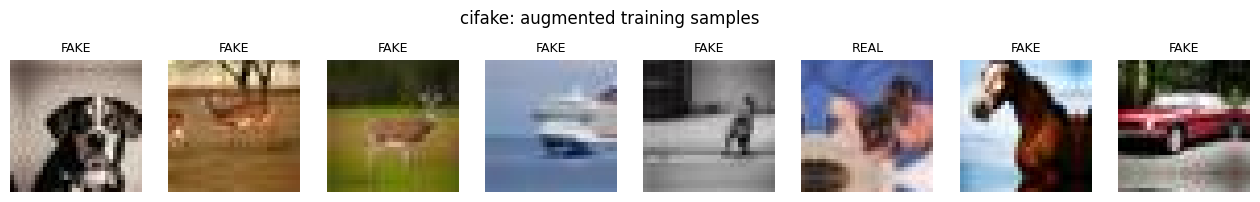

   training SimpleCNN (1,206,370 trainable params)
     scratch ep  1/30 | lr 1.0e-03 | train loss 0.368 acc 0.898 | val loss 0.338 acc 0.917 f1 0.917 | 108.9s ★
     scratch ep  2/30 | lr 1.0e-03 | train loss 0.322 acc 0.928 | val loss 0.299 acc 0.940 f1 0.940 | 65.4s ★
     scratch ep  3/30 | lr 9.9e-04 | train loss 0.308 acc 0.936 | val loss 0.295 acc 0.943 f1 0.943 | 64.3s ★
     scratch ep  4/30 | lr 9.8e-04 | train loss 0.297 acc 0.943 | val loss 0.287 acc 0.948 f1 0.948 | 64.4s ★
     scratch ep  5/30 | lr 9.6e-04 | train loss 0.291 acc 0.947 | val loss 0.387 acc 0.894 f1 0.893 | 62.7s 
     scratch ep  6/30 | lr 9.3e-04 | train loss 0.285 acc 0.951 | val loss 0.276 acc 0.955 f1 0.955 | 63.9s ★
     scratch ep  7/30 | lr 9.0e-04 | train loss 0.280 acc 0.953 | val loss 0.266 acc 0.961 f1 0.961 | 63.6s ★
     scratch ep  8/30 | lr 8.7e-04 | train loss 0.275 acc 0.956 | val loss 0.267 acc 0.961 f1 0.961 | 63.9s 
     scratch ep  9/30 | lr 8.3e-04 | train loss 0.272 acc 0.958 | val 

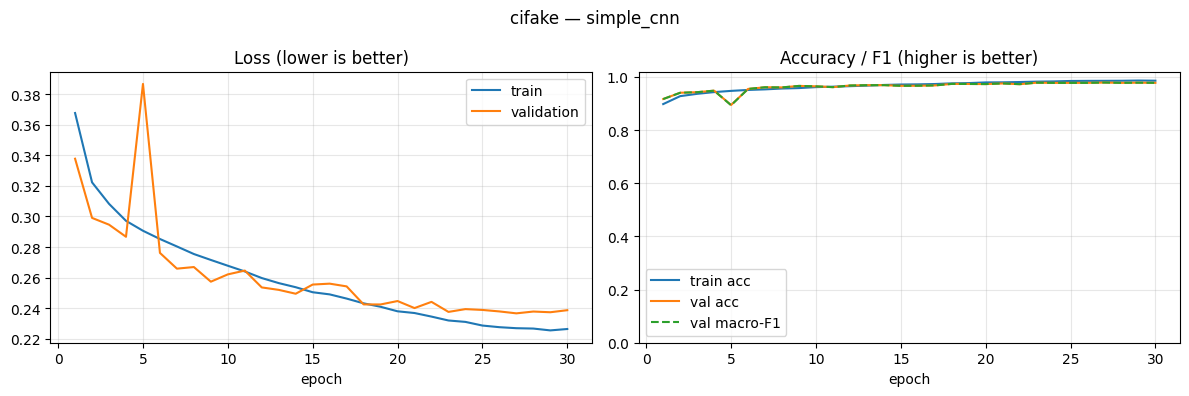

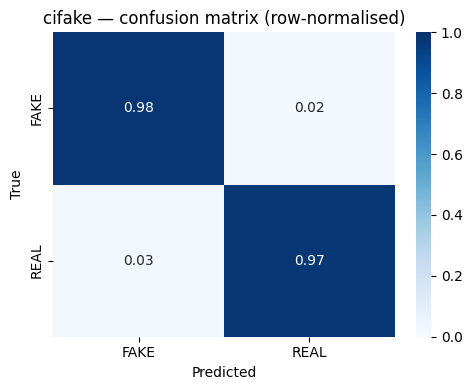

   💾 saved /content/results/cifake_simple_cnn.pt

Finished 1 dataset(s).


In [10]:
# ==================== STEP 8: TRAIN ON THE DATASET(S) ====================
ALL_HISTORIES = {}                                              # epoch logs per run, for the comparison plot later


def run_experiment(entry, cfg):
    name = entry["name"]                                        # dataset label
    set_seed(cfg["seed"])                                       # identical randomness for every dataset
    root = fetch_dataset(entry)                                 # download / extract / locate
    data_dir = find_image_root(root)                            # skip wrapper folders
    print(f"   data folder: {data_dir}")
    train_loader, val_loader, test_loader, classes, train_y = make_loaders(data_dir, cfg)   # splits + loaders
    n_cls = len(classes)                                        # number of classes
    n_tr, n_va, n_te = (len(l.dataset) for l in (train_loader, val_loader, test_loader))   # split sizes
    print(f"   {n_cls} classes | train {n_tr} | val {n_va} | test {n_te}")
    print(f"   classes: {classes[:15]}{' ...' if n_cls > 15 else ''}")
    counts = np.bincount(train_y, minlength=n_cls)              # training images per class
    print(f"   train images per class: min {counts.min()}, max {counts.max()}")   # imbalance check
    if cfg["show_plots"]:
        show_samples(train_loader, classes, f"{name}: augmented training samples")  # eyeball the input

    set_seed(cfg["seed"])                                       # re-seed so plotting samples above doesn't change training
    model = build_model(cfg["model"], n_cls, cfg).to(DEVICE)    # create the network and move it to the GPU
    class_weights = None                                        # default: all classes weigh the same
    if cfg["use_class_weights"]:                                # inverse-frequency weights: rare class -> bigger weight
        w = counts.sum() / (n_cls * np.maximum(counts, 1))
        class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)

    history, t0 = [], time.time()                               # epoch log and total timer
    if cfg["model"] == "resnet18":                              # two-phase transfer learning
        set_backbone_trainable(model, False)                    # phase 1: freeze everything except the head
        print(f"   phase 1 — head only ({count_params(model):,} trainable params)")
        head_f1 = fit(model, train_loader, val_loader, cfg, cfg["freeze_epochs"], cfg["lr"], class_weights, history, "head")
        set_backbone_trainable(model, True)                     # phase 2: unfreeze the whole network
        print(f"   phase 2 — full fine-tune ({count_params(model):,} trainable params)")
        fit(model, train_loader, val_loader, cfg, cfg["epochs"] - cfg["freeze_epochs"],
            cfg["lr"] * cfg["finetune_lr_factor"], class_weights, history, "finetune", best_f1=head_f1)  # must BEAT phase 1 to replace it
    else:                                                       # from-scratch CNN: one phase
        print(f"   training SimpleCNN ({count_params(model):,} trainable params)")
        fit(model, train_loader, val_loader, cfg, cfg["epochs"], cfg["lr"], class_weights, history, "scratch")
    train_min = (time.time() - t0) / 60                         # training time in minutes

    _, y_true, y_pred = evaluate(model, test_loader, nn.CrossEntropyLoss())   # FINAL score on untouched test data
    metrics = compute_metrics(y_true, y_pred)                   # all summary metrics
    print(f"\n   ✅ TEST  acc {metrics['accuracy']:.4f} | macro P {metrics['precision_macro']:.4f} "
          f"R {metrics['recall_macro']:.4f} F1 {metrics['f1_macro']:.4f}\n")
    print(classification_report(y_true, y_pred, labels=range(n_cls), target_names=classes,
                                digits=3, zero_division=0))     # per-class breakdown
    if cfg["show_plots"]:
        plot_history(history, f"{name} — {cfg['model']}")       # learning curves
        plot_confusion(y_true, y_pred, classes, f"{name} — confusion matrix (row-normalised)")

    os.makedirs(cfg["save_dir"], exist_ok=True)                 # make the results folder
    ckpt = os.path.join(cfg["save_dir"], f"{name}_{cfg['model']}.pt")    # checkpoint file name
    torch.save({"state_dict": model.state_dict(), "classes": classes, "config": cfg}, ckpt)  # weights + metadata
    print(f"   💾 saved {ckpt}")
    ALL_HISTORIES[(name, cfg["model"])] = history               # keep curves for the comparison plot

    del model; torch.cuda.empty_cache() if DEVICE.type == "cuda" else None   # free GPU memory before the next dataset
    return {"dataset": name, "model": cfg["model"], "num_classes": n_cls,     # one row of the results table
            "train_imgs": n_tr, "val_imgs": n_va, "test_imgs": n_te,
            "chance_accuracy": 1 / n_cls, **metrics,
            "epochs_run": len(history), "train_minutes": round(train_min, 2)}


results = []                                                    # one dict per finished dataset
for entry in DATASETS:                                          # train on each dataset in turn
    src = entry.get("link") or entry.get("path") or ""          # whatever the user filled in
    if not src or "PASTE" in src:                               # placeholder still there
        print(f"⏭  skipping '{entry['name']}' — paste your Drive link into DATASET_LINK in Step 2 first")
        continue
    print("=" * 100 + f"\n📂 {entry['name']}  ({CONFIG['model']})\n" + "=" * 100)
    try:
        results.append(run_experiment(entry, CONFIG))           # train + evaluate, keep the scores
    except Exception:                                           # one bad dataset shouldn't stop the rest
        traceback.print_exc()                                   # show the full error
        print(f"❌ '{entry['name']}' failed — see the error above. Continuing with the next dataset.")
print(f"\nFinished {len(results)} dataset(s).")

,model,num_classes,train_imgs,val_imgs,test_imgs,chance_accuracy,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,epochs_run,train_minutes
dataset,,,,,,,,,,,,,,,
cifake,simple_cnn,2,85000,15000,20000,0.5,0.9756,0.9756,0.9756,0.9755,0.9756,0.9756,0.9755,30,32.34


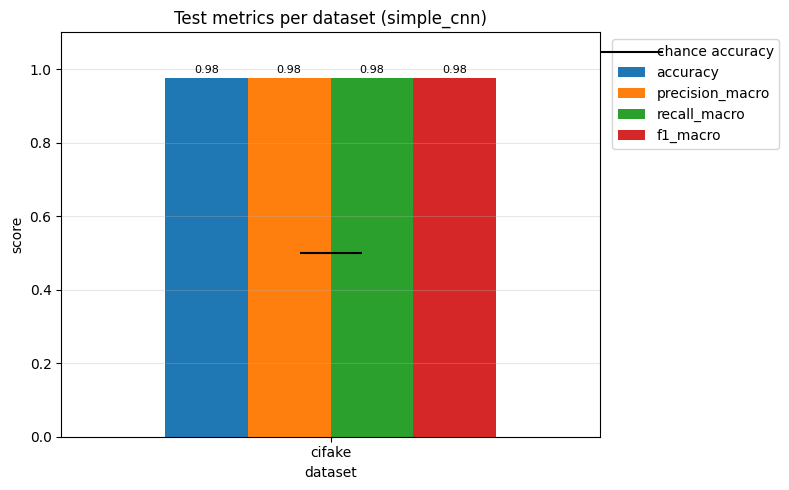

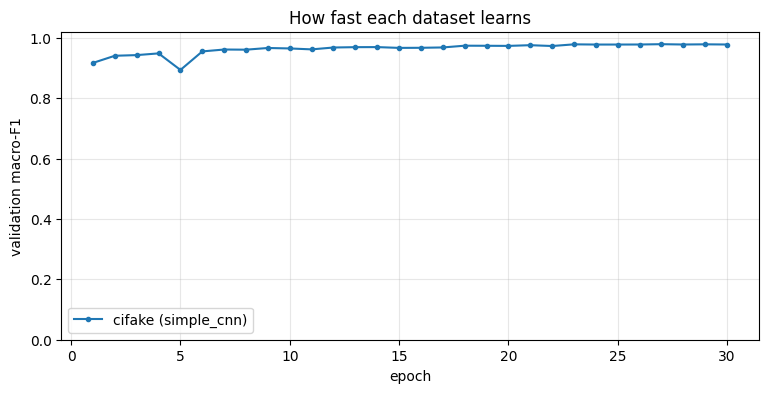

Saved /content/results/comparison_simple_cnn.csv


In [11]:
# ==================== STEP 9: COMPARE RESULTS ====================
if results:                                                             # only if at least one dataset finished
    df = pd.DataFrame(results).set_index("dataset")                     # rows = datasets, columns = metrics
    display(df.round(4))                                                # pretty table rounded to 4 decimals

    cols = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]  # the headline metrics to chart
    ax = df[cols].plot(kind="bar", figsize=(max(8, 2.5 * len(df)), 5), rot=0, width=0.8)  # grouped bars
    for c in ax.containers:                                             # each metric's set of bars
        ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)              # print the value on every bar
    ax.scatter(range(len(df)), df["chance_accuracy"], marker="_", s=2000, color="black",
               zorder=3, label="chance accuracy")                       # black tick = random-guess level
    ax.set(ylim=(0, 1.1), ylabel="score", title=f"Test metrics per dataset ({CONFIG['model']})")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1)); ax.grid(axis="y", alpha=0.3)   # legend outside the plot
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(9, 4))                                          # overlaid validation-F1 curves
    for (ds, mdl), hist in ALL_HISTORIES.items():                       # every run we did
        h = pd.DataFrame(hist)
        plt.plot(h["epoch"], h["val_f1"], marker="o", ms=3, label=f"{ds} ({mdl})")
    plt.xlabel("epoch"); plt.ylabel("validation macro-F1"); plt.ylim(0, 1.02)
    plt.title("How fast each dataset learns"); plt.legend(); plt.grid(alpha=0.3); plt.show()

    os.makedirs(CONFIG["save_dir"], exist_ok=True)                      # make sure the folder exists
    csv_path = os.path.join(CONFIG["save_dir"], f"comparison_{CONFIG['model']}.csv")
    df.to_csv(csv_path)                                                 # save the table
    print("Saved", csv_path)
    if CONFIG["save_to_drive"] and IN_COLAB:                            # optional: copy results to your Drive
        mount_drive_if_needed("/content/drive")
        out = "/content/drive/MyDrive/cnn_results"
        shutil.copytree(CONFIG["save_dir"], out, dirs_exist_ok=True)    # copy checkpoints + CSV
        print("Copied results to", out)
else:
    print("No results yet — run Step 8 with at least one link filled in.")

In [12]:
# ==================== STEP 10: EXPERIMENTS — SCRATCH CNN vs FINE-TUNED RESNET-18 ====================
EXPERIMENTS = [                                     # each dict overrides CONFIG for one experiment — add your own!
    {"model": "simple_cnn"},                        # baseline: our CNN from scratch
    {"model": "resnet18", "image_size": 128, "epochs": 12},   # pretrained ResNet-18: needs bigger images (32px shrinks to 1x1 inside it)
    # {"model": "simple_cnn", "dropout": 0.5, "weight_decay": 5e-4},   # example: stronger regularisation
    # {"model": "simple_cnn", "image_size": 64},                       # example: lower resolution (faster)
]

exp_rows = []                                       # results of every (experiment, dataset) pair
for i, overrides in enumerate(EXPERIMENTS):         # loop over experiments
    cfg = {**CONFIG, **overrides, "show_plots": False}   # copy CONFIG, apply overrides, skip per-run plots for speed
    tag = ", ".join(f"{k}={v}" for k, v in overrides.items())   # readable experiment label
    for entry in DATASETS:                          # every dataset
        src = entry.get("link") or entry.get("path") or ""
        if not src or "PASTE" in src:               # skip placeholders
            continue
        print("=" * 100 + f"\n🧪 [{tag}]  on  {entry['name']}\n" + "=" * 100)
        try:
            row = run_experiment(entry, cfg)        # same function as Step 8
            row["experiment"] = tag                 # remember which settings produced it
            exp_rows.append(row)
        except Exception:
            traceback.print_exc()

if exp_rows:
    exp_df = pd.DataFrame(exp_rows)                 # all runs in one table
    print("\nTest macro-F1  (rows = dataset, columns = experiment)")
    display(exp_df.pivot_table(index="dataset", columns="experiment", values="f1_macro").round(4))   # F1 grid
    print("Test accuracy")
    display(exp_df.pivot_table(index="dataset", columns="experiment", values="accuracy").round(4))   # accuracy grid
    exp_df.to_csv(os.path.join(CONFIG["save_dir"], "experiments.csv"), index=False)                  # save everything

🧪 [model=simple_cnn]  on  cifake
   data folder: /content/data/cifake/CIFAKE-Real-and-AI-Generated-Synthetic-Images-main/DATASET
   layout: pre-split folders -> test, train
   2 classes | train 85000 | val 15000 | test 20000
   classes: ['FAKE', 'REAL']
   train images per class: min 42500, max 42500
   training SimpleCNN (1,206,370 trainable params)
     scratch ep  1/30 | lr 1.0e-03 | train loss 0.368 acc 0.898 | val loss 0.338 acc 0.917 f1 0.917 | 61.8s ★
     scratch ep  2/30 | lr 1.0e-03 | train loss 0.322 acc 0.928 | val loss 0.299 acc 0.940 f1 0.940 | 62.0s ★
     scratch ep  3/30 | lr 9.9e-04 | train loss 0.308 acc 0.936 | val loss 0.295 acc 0.943 f1 0.943 | 61.7s ★
     scratch ep  4/30 | lr 9.8e-04 | train loss 0.297 acc 0.943 | val loss 0.287 acc 0.948 f1 0.948 | 61.7s ★
     scratch ep  5/30 | lr 9.6e-04 | train loss 0.291 acc 0.947 | val loss 0.387 acc 0.894 f1 0.893 | 62.4s 
     scratch ep  6/30 | lr 9.3e-04 | train loss 0.285 acc 0.951 | val loss 0.276 acc 0.955 f1 0.95

100%|██████████| 44.7M/44.7M [00:00<00:00, 152MB/s]

   phase 1 — head only (1,026 trainable params)


        head ep  1/3 | lr 1.0e-03 | train loss 0.503 acc 0.794 | val loss 0.432 acc 0.856 f1 0.856 | 120.1s ★
        head ep  2/3 | lr 7.5e-04 | train loss 0.484 acc 0.810 | val loss 0.441 acc 0.849 f1 0.848 | 119.2s 
        head ep  3/3 | lr 2.5e-04 | train loss 0.479 acc 0.813 | val loss 0.432 acc 0.859 f1 0.859 | 118.2s ★
   phase 2 — full fine-tune (11,177,538 trainable params)
    finetune ep  1/9 | lr 1.0e-04 | train loss 0.298 acc 0.948 | val loss 0.251 acc 0.972 f1 0.972 | 151.0s ★
    finetune ep  2/9 | lr 9.7e-05 | train loss 0.253 acc 0.972 | val loss 0.237 acc 0.979 f1 0.979 | 129.1s ★
    finetune ep  3/9 | lr 8.8e-05 | train loss 0.238 acc 0.981 | val loss 0.235 acc 0.978 f1 0.978 | 130.0s 
    finetune ep  4/9 | lr 7.5e-05 | train loss 0.228 acc 0.985 | val loss 0.228 acc 0.983 f1 0.983 | 129.1s ★
    finetune ep  5/9 | lr 5.9e-05 | train loss 0.224 acc 0.988 | val loss 0.227 acc 0.983 f1 0.983 | 129.2s ★
    finetune ep  6/9 | lr 4.1e-05 | train loss 0.217 acc 0.992 |

experiment,"model=resnet18, image_size=128, epochs=12",model=simple_cnn
dataset,,
cifake,0.9869,0.9755


Test accuracy


experiment,"model=resnet18, image_size=128, epochs=12",model=simple_cnn
dataset,,
cifake,0.9869,0.9756


In [13]:
# ==================== STEP 11: PREDICT ON A NEW IMAGE ====================
from google.colab import files                                               # Colab's upload helper
up = files.upload()                                                          # click "Choose files" -> pick AI_Generated_Cat.jpeg from your Desktop
IMAGE_PATH = "/content/" + next(iter(up))                                    # path of the uploaded image inside Colab
CHECKPOINT = os.path.join(CONFIG["save_dir"], "cifake_resnet18.pt")          # or "cifake_simple_cnn.pt" to test the scratch CNN                                 # the image you want to classify

if os.path.exists(CHECKPOINT) and os.path.exists(IMAGE_PATH):               # only run when both files exist
    ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)  # weights + class names + config
    cfg, classes = ckpt["config"], ckpt["classes"]                          # unpack metadata
    model = build_model(cfg["model"], len(classes), cfg).to(DEVICE)         # same architecture as during training
    model.load_state_dict(ckpt["state_dict"]); model.eval()                 # restore weights, switch to eval mode
    _, eval_tf = build_transforms(cfg["image_size"], augment=False)         # the exact test-time preprocessing
    x = eval_tf(Image.open(IMAGE_PATH).convert("RGB")).unsqueeze(0).to(DEVICE)   # load -> tensor -> add batch dim -> GPU
    with torch.no_grad():                                                   # inference only
        probs = torch.softmax(model(x), dim=1)[0]                           # probabilities for each class
    top = torch.topk(probs, k=min(3, len(classes)))                         # top-3 guesses
    for p, i in zip(top.values, top.indices):                               # print them
        print(f"{classes[i]:<25} {p.item():.1%}")
    plt.imshow(Image.open(IMAGE_PATH)); plt.axis("off"); plt.title(classes[top.indices[0]]); plt.show()
else:
    print("Set CHECKPOINT and IMAGE_PATH to existing files first.")

Set CHECKPOINT and IMAGE_PATH to existing files first.
